## **Review of Basic ML Algorithms**

Machine learning (ML) is the study of computer algorithms that can automatically improve through experience and the use of data. It is considered part of artificial intelligence. Machine learning algorithms build a model based on sample data, called "training data", to make predictions or decisions without being explicitly programmed to do so.

#### **Approaches**

Machine learning approaches are traditionally divided into three broad categories, depending on the nature of the "signal" or "feedback" available to the learning system:

* **Supervised learning:** 
The computer is presented with example inputs and their desired outputs, given by a "teacher", and the goal is to learn a general rule that maps inputs to outputs.
* **Unsupervised learning:** 
No labels are given to the learning algorithm, leaving it on its own to find structure in its input. Unsupervised learning can be a goal in itself (discovering hidden patterns in data) or a means towards an end (feature learning).
* **Reinforcement learning:**
A computer program interacts with a dynamic environment in which it must perform a certain goal (such as driving a vehicle or playing a game against an opponent). As it navigates its problem space, the program is provided feedback that's analogous to rewards, which it tries to maximize.

![https://www.boozallen.com/content/boozallen/en/author-groups/sig/si-group/insight/blog/how-do-machines-learn/_jcr_content/blog_block/parsys/image_1690394832.img.png/1646949920451.png](https://www.boozallen.com/content/boozallen/en/author-groups/sig/si-group/insight/blog/how-do-machines-learn/_jcr_content/blog_block/parsys/image_1690394832.img.png/1646949920451.png)
> Source: https://www.boozallen.com/assets/boozallen_site/sig/pdf/infographic/how-do-machines-learn.pdf

## **Examples**

Below are some examples of the use of selected machine learning algorithms. These examples are based on a very simple data set in order to show the effects of using these algorithms as clearly as possible. In addition, the examples use popular and useful modules such as "pandas", "numpy", or "matplotlib" to show their basic practical application.

Keep in mind that the data set is very small. Therefore, the accuracy of the models presented may be very low.

I hope that the following examples will dispel the doubts of people who have just started their adventure with machine learning. A few simple, practical examples can teach you more than reading a dozen pages of machine learning theory.

---
### **Ex. 1: Nearest Neighbors Algorithm**
Machine Learning > Supervised Learning > Classification > K-NN

> Take a look: https://scikit-learn.org/stable/modules/neighbors.html

In [1]:
# Import required functions
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()


# Input data
X_data = np.array([[12, 5],
                   [15, 4],
                   [8, 5],
                   [7, 7],
                   [-1, 3],
                   [-2, 8],
                   [-8, 7],
                   [-5, 10],
                   [-2, 8],
                   [-5, -4],
                   [-4, -10],
                   [-8, -6]])

y_data = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2])

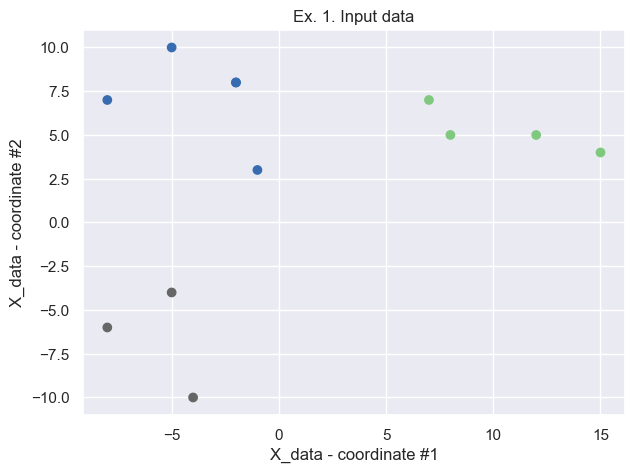

In [2]:
# Data visualization - general
plt.figure(figsize = (7, 5))
plt.scatter(X_data[:, 0], X_data[:, 1], c = y_data, cmap = 'Accent')

plt.title('Ex. 1. Input data')
plt.xlabel('X_data - coordinate #1')
plt.ylabel('X_data - coordinate #2')

plt.show()

In [3]:
# Split the data set into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.2)

# Build the model and set up the training set
knn = KNeighborsClassifier(n_neighbors = 1).fit(X_train, y_train)

# Predict the results for the test set
y_pred = knn.predict(X_test)

# Verify the accuracy of the model
acc = metrics.accuracy_score(y_test, y_pred)

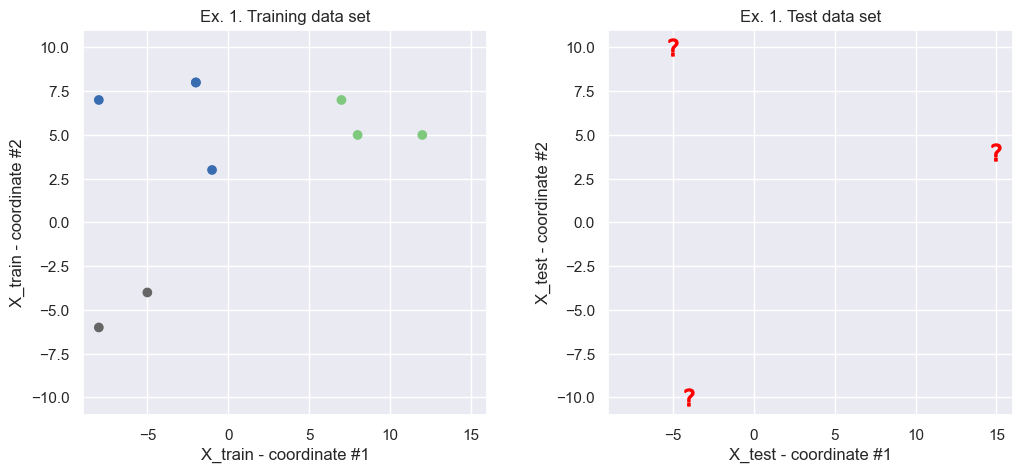

In [4]:
# Data visualization - separation into test and training sets
fig = plt.figure(figsize = (12, 5))

plt.subplot(121)
plt.scatter(X_train[:, 0], X_train[:, 1], c = y_train, cmap = 'Accent')
plt.title('Ex. 1. Training data set')
plt.xlabel('X_train - coordinate #1')
plt.ylabel('X_train - coordinate #2')
plt.xlim(-9, 16)
plt.ylim(-11, 11)

plt.subplot(122)
plt.scatter(X_test[:, 0], X_test[:, 1], c = 'red', s = 150, marker = '$?$')
plt.title('Ex. 1. Test data set')
plt.xlabel('X_test - coordinate #1')
plt.ylabel('X_test - coordinate #2')
plt.xlim(-9, 16)
plt.ylim(-11, 11)

plt.subplots_adjust(wspace = 0.3)
plt.show()

In [5]:
# Results and accuracy
pd.DataFrame({'X_test - coordinate #1': X_test[:, 0], 
              'X_test - coordinate #2': X_test[:, 1], 
              'Primary category (y_test)': y_test, 
              'Category predicted by the model (y_pred)': y_pred})

,X_test - coordinate #1,X_test - coordinate #2,Primary category (y_test),Category predicted by the model (y_pred)
0,-4,-10,2,2
1,-5,10,1,1
2,15,4,0,0


In [6]:
print(f'The accuracy of the classification of points from the test set is {acc * 100 :.1f}%.')

The accuracy of the classification of points from the test set is 100.0%.


---
### **Ex. 2: Naive Bayes**
Machine Learning > Supervised Learning > Classification > Naive Bayes

> Take a look: https://scikit-learn.org/stable/modules/naive_bayes.html

In [7]:
# Import required functions
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd

# Input data
X_data = np.array([[2, 10, 1],
                   [4, 11, 2],
                   [3, 12, 1],
                   [4, 9, 3],
                   [-3, -10, 10],
                   [-3, -11, 9],
                   [-4, -12, 8],
                   [-5, -9, 11],
                   [-3, 10, 1],
                   [-3, 11, 2],
                   [-4, 9, 3],
                   [-5, 12, 1]])

y_data = np.array([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2])

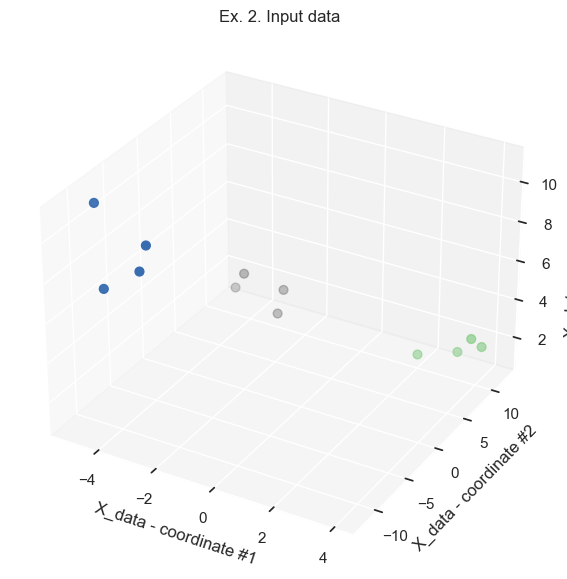

In [8]:
# Data visualization - general
fig = plt.figure(figsize = (9, 7), facecolor = 'white')
ax = fig.add_subplot(projection = '3d')

ax.scatter(X_data[:, 0], X_data[:, 1], X_data[:, 2], c = y_data, s = 40, cmap = 'Accent')
ax.set(xlabel = 'X_data - coordinate #1', 
       ylabel = 'X_data - coordinate #2', 
       zlabel = 'X_data - coordinate #3', 
       title = 'Ex. 2. Input data', facecolor = 'white')
plt.show()

In [9]:
# Split the data set into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.2)

# Build the model and set up the training set
nb = BernoulliNB().fit(X_train, y_train)

# Predict the results for the test set
y_pred = nb.predict(X_test)

# Verify the accuracy of the model
acc = metrics.accuracy_score(y_test, y_pred)

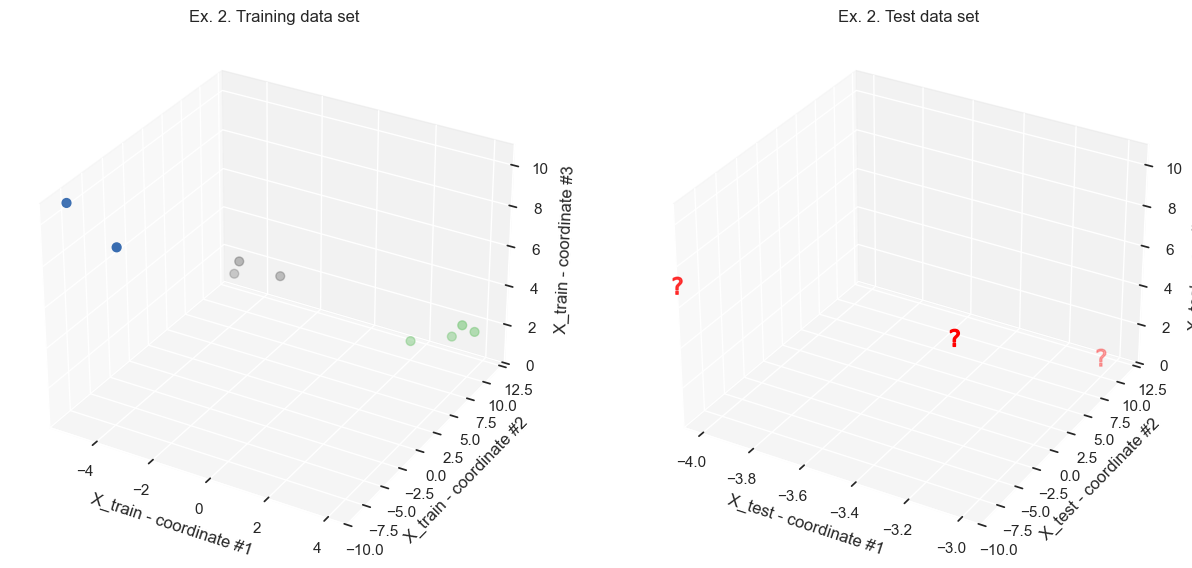

In [10]:
# Data visualization - separation into test and training sets
fig = plt.figure(figsize = (15, 7), facecolor = 'white')

ax1 = fig.add_subplot(1, 2, 1, projection = '3d')
ax1.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c = y_train, s = 40, cmap = 'Accent')
ax1.set(xlabel = 'X_train - coordinate #1', 
        ylabel = 'X_train - coordinate #2', 
        zlabel = 'X_train - coordinate #3', 
        title = 'Ex. 2. Training data set', facecolor = 'white')
ax1.set_xlim,(-6, 5)
ax1.set_ylim(-10, 13)
ax1.set_zlim(-0, 11)

ax2 = fig.add_subplot(1, 2, 2, projection = '3d')
ax2.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c = 'red', s = 150, marker = '$?$')
ax2.set(xlabel = 'X_test - coordinate #1', 
        ylabel = 'X_test - coordinate #2', 
        zlabel = 'X_test - coordinate #3', 
        title = 'Ex. 2. Test data set', facecolor = 'white')
ax2.set_xlim,(-6, 5)
ax2.set_ylim(-10, 13)
ax2.set_zlim(-0, 11)

plt.show()

In [11]:
# Results and accuracy
pd.DataFrame({'X_test - coordinate #1': X_test[:, 0], 
              'X_test - coordinate #2': X_test[:, 1], 
              'X_test - coordinate #3': X_test[:, 2], 
              'Primary category (y_test)': y_test, 
              'Category predicted by the model (y_pred)': y_pred})

,X_test - coordinate #1,X_test - coordinate #2,X_test - coordinate #3,Primary category (y_test),Category predicted by the model (y_pred)
0,-3,10,1,2,2
1,-3,-11,9,1,1
2,-4,-12,8,1,1


In [12]:
print(f'The accuracy of the classification of points from the test set is {acc * 100 :.1f}%.')

The accuracy of the classification of points from the test set is 100.0%.


---
### **Ex. 3: Decision Tree**
Machine Learning > Supervised Learning > Classification > Decision Tree

> Take a look: https://scikit-learn.org/stable/modules/tree.html

In [13]:
# Import required functions
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

import numpy as np
import pandas as pd

# Input data
# The number 1 in the matrix / vector forms the shape of the corresponding number 
X_data = np.array([[1,1,1,1,1,
                    1,0,0,0,1,
                    1,0,0,0,1,
                    1,0,0,0,1,
                    1,1,1,1,1], # number 0, version I
                   
                   [0,1,1,1,0,
                    1,0,0,0,1,
                    1,0,0,0,1,
                    1,0,0,0,1,
                    0,1,1,1,0], # number 0, version II
                   
                   [0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0], # number 1, version I
                   [0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0], # number 1, version II
                   [0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0], # number 1, version III
                   
                   [1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,0,0,1,1,1,1,1], # number 2, version I
                   [1,1,1,1,0,0,0,0,0,1,0,1,1,1,0,1,0,0,0,0,1,1,1,1,1], # number 2, version II
                   [1,1,1,1,0,0,0,0,0,1,0,1,1,1,0,1,0,0,0,0,0,1,1,1,1], # number 2, version III
                   
                   [1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1], # number 3, version I
                   [1,1,1,1,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1,0], # number 3, version II
                   [1,1,1,1,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,1,1,1,1,0], # number 3, version III
                   
                   [1,0,0,0,1,1,0,0,0,1,1,1,1,1,1,0,0,0,0,1,0,0,0,0,1], # number 4, version I
                   [1,0,0,0,1,1,0,0,0,1,0,1,1,1,1,0,0,0,0,1,0,0,0,0,1], # number 4, version II
                   [0,0,1,0,1,0,1,0,0,1,1,1,1,1,1,0,0,0,0,1,0,0,0,0,1], # number 4, version III
                   
                   [1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1], # number 5, version I
                   [1,1,1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,1,1,1,1,1,0], # number 5, version II
                   [0,1,1,1,1,1,0,0,0,0,0,1,1,1,0,0,0,0,0,1,1,1,1,1,0], # number 5, version III
                   
                   [1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1], # number 6, version I
                   [0,1,1,1,1,1,0,0,0,0,1,1,1,1,0,1,0,0,0,1,0,1,1,1,0], # number 6, version II
                   [0,1,1,1,1,1,0,0,0,0,1,1,1,1,0,1,0,0,0,1,1,1,1,1,0], # number 6, version III
                   
                   [1,1,1,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1], # number 7, version I
                   [0,1,1,1,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1], # number 7, version II
                   [1,1,1,1,1,0,0,0,0,1,0,0,1,1,1,0,0,0,0,1,0,0,0,0,1], # number 7, version III
                   
                   [1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1], # number 8, version I
                   [0,1,1,1,0,1,0,0,0,1,0,1,1,1,0,1,0,0,0,1,0,1,1,1,0], # number 8, version II
                   [1,1,1,1,1,1,0,0,0,1,0,1,1,1,0,1,0,0,0,1,1,1,1,1,1], # number 8, version III
                   
                   [1,1,1,1,1,
                    1,0,0,0,1,
                    1,1,1,1,1,
                    0,0,0,0,1,
                    1,1,1,1,1], # number 9, version I
                   
                   [0,1,1,1,0,
                    1,0,0,0,1,
                    0,1,1,1,1,
                    0,0,0,0,1,
                    1,1,1,1,0], # number 9, version II

                   [0,1,1,1,1,
                    1,0,0,0,1,
                    0,1,1,1,1,
                    0,0,0,0,1,
                    1,1,1,1,0]]) # number 9, version III


y_data = np.array([0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9])

y_data_info = np.array(['number 0, version I', 'number 0, version II',
                        'number 1, version I', 'number 1, version II', 'number 1, version II',
                        'number 2, version I', 'number 2, version II', 'number 2, version II',
                        'number 3, version I', 'number 3, version II', 'number 3, version II',
                        'number 4, version I', 'number 4, version II', 'number 4, version II',
                        'number 5, version I', 'number 5, version II', 'number 5, version II',
                        'number 6, version I', 'number 6, version II', 'number 6, version II',
                        'number 7, version I', 'number 7, version II', 'number 7, version II',
                        'number 8, version I', 'number 8, version II', 'number 8, version II',
                        'number 9, version I', 'number 9, version II', 'number 9, version II'])

In [14]:
# Split the data set into test and training sets
X_train, X_test, y_train, y_test, y_train_info, y_test_info = train_test_split(X_data, y_data, y_data_info, test_size = 0.1)

# Build the model and set up the training set
tree = DecisionTreeClassifier().fit(X_train, y_train)

# Predict the results for the test set
y_pred = tree.predict(X_test)

# Verify the accuracy of the model
acc = metrics.accuracy_score(y_test, y_pred)

In [15]:
# Results and accuracy
pd.DataFrame({'Primary category (y_test)': y_test, 
              'Detailed information (y_test_info)': y_test_info, 
              'Category predicted by the model (y_pred)': y_pred})

,Primary category (y_test),Detailed information (y_test_info),Category predicted by the model (y_pred)
0,1,"number 1, version I",1
1,8,"number 8, version II",8
2,6,"number 6, version II",6


In [16]:
print(f'The accuracy of the classification of data from the test set is {acc * 100 :.1f}%.')

The accuracy of the classification of data from the test set is 100.0%.


---
### **Ex. 4. Linear Regression**
Machine Learning > Supervised Learning > Regression > Linear Regression

> Take a look: https://scikit-learn.org/stable/modules/linear_model.html

In [17]:
# Import required functions
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd

# Input data
Xy_data = np.array([[0, 2300],
                    [1, 2500],
                    [2, 3200],
                    [3, 3800],
                    [4, 4200],
                    [5, 4800],
                    [6, 5000],
                    [7, 5200],
                    [8, 6000],
                    [9, 6900]])

X_data = Xy_data[:, 0].reshape((-1, 1))
y_data = Xy_data[:, 1]

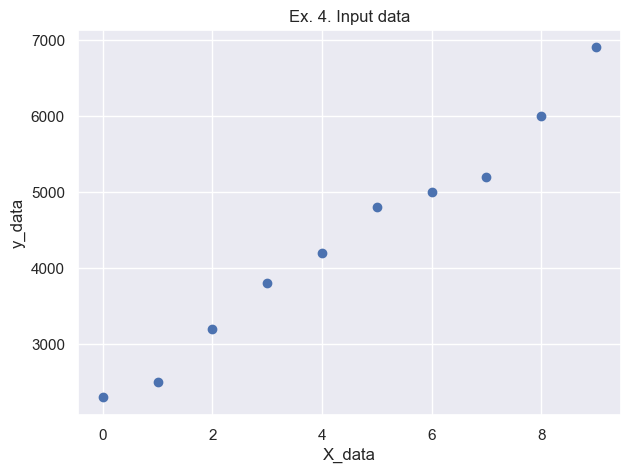

In [18]:
# Data visualization - general
plt.figure(figsize = (7, 5))
plt.scatter(X_data, y_data)

plt.title('Ex. 4. Input data')
plt.xlabel('X_data')
plt.ylabel('y_data')

plt.show()

In [19]:
# Split the data set into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.3)

# Build the model and set up the training set
linreg = LinearRegression().fit(X_train, y_train)

# Predict the results for the test set
y_pred = linreg.predict(X_test)

# Verify the accuracy of the model
mae = metrics.mean_absolute_error(y_test, y_pred)

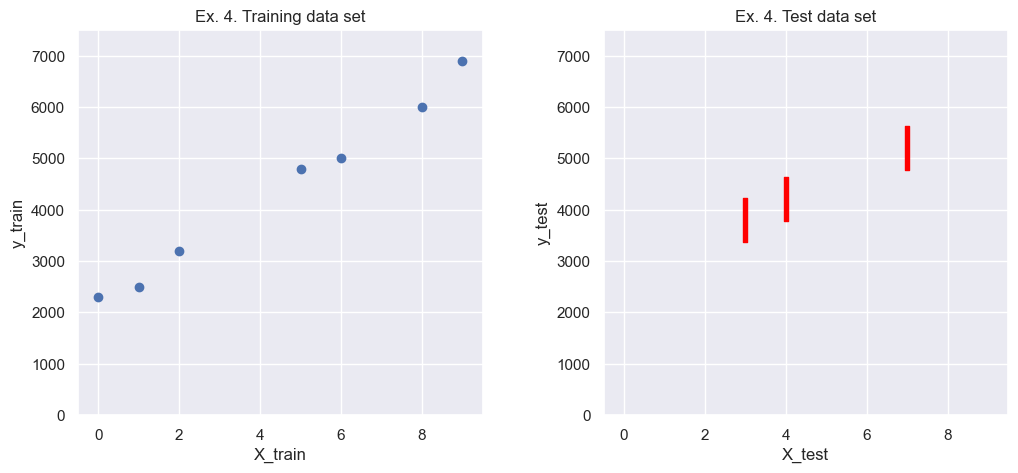

In [20]:
# Data visualization - separation into test and training sets
fig = plt.figure(figsize = (12, 5))

plt.subplot(121)
plt.scatter(X_train, y_train)
plt.title('Ex. 4. Training data set')
plt.xlabel('X_train')
plt.ylabel('y_train')
plt.xlim(-0.5, 9.5)
plt.ylim(0, 7500)

plt.subplot(122)
plt.scatter(X_test, y_test, c = 'red', s = 1000, marker = '$|$')
plt.title('Ex. 4. Test data set')
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.xlim(-0.5, 9.5)
plt.ylim(0, 7500)

plt.subplots_adjust(wspace = 0.3)
plt.show()

In [21]:
# Results and absolute error
pd.DataFrame({'Designation (X_test)': X_test[:, 0], 
              'Actual value (y_test)': y_test, 
              'Value predicted by the model (y_pred)': y_pred, 
              'Difference': abs(y_pred - y_test)})

,Designation (X_test),Actual value (y_test),Value predicted by the model (y_pred),Difference
0,3,3800,3667.829457,132.170543
1,4,4200,4170.348837,29.651163
2,7,5200,5677.906977,477.906977


In [22]:
print(f'The absolute error is {mae:.1f}')

The absolute error is 213.2


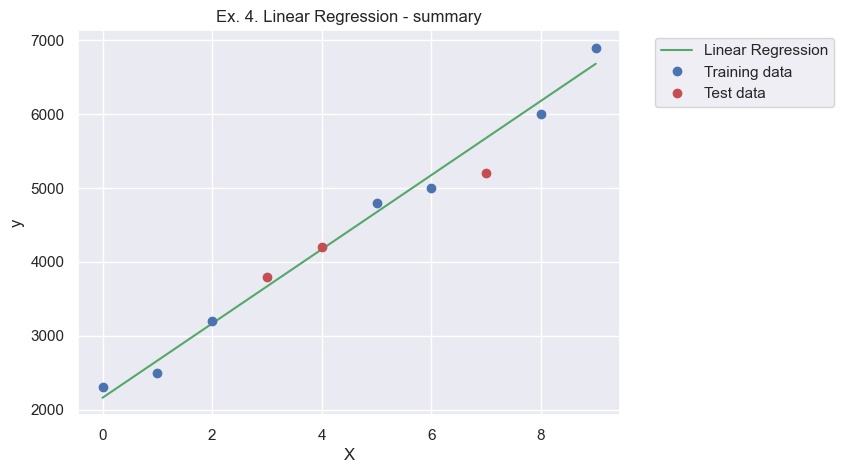

In [23]:
# Data visualization - summary
def y(x):
    a = linreg.coef_
    b = linreg.intercept_
    
    return a*x + b

x = np.linspace(0, 9, 100)

fig = plt.figure(figsize = (7, 5))
plt.plot(x, y(x), 'g-', label = 'Linear Regression')
plt.plot(X_train, y_train, 'bo', label = 'Training data')
plt.plot(X_test, y_test, 'ro', label = 'Test data')

plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.title('Ex. 4. Linear Regression - summary')
plt.xlabel('X')
plt.ylabel('y')

plt.show()

---
### **Ex. 5. Polynomial Regression**
Machine Learning > Supervised Learning > Regression > Polynomial Regression

> Take a look: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

In [24]:
# Import required functions
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd

# Input data
Xy_data = np.array([[0, 1300],
                    [1, 2500],
                    [2, 3200],
                    [3, 3800],
                    [4, 3200],
                    [5, 3800],
                    [6, 5500],
                    [7, 6200],
                    [8, 6000],
                    [9, 5200]])

X_data = Xy_data[:, 0].reshape((-1, 1))
y_data = Xy_data[:, 1]

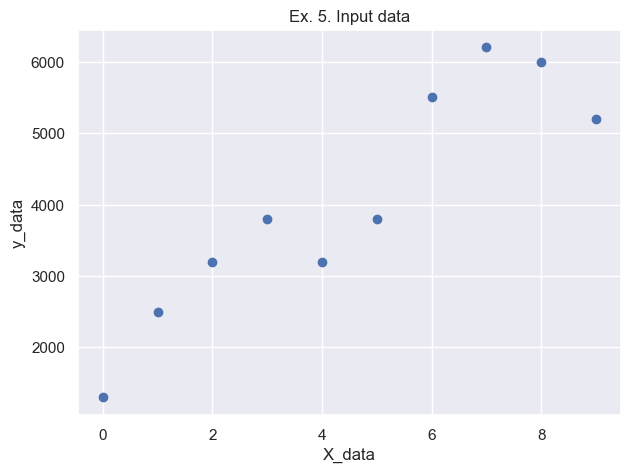

In [25]:
# Data visualization - general
plt.figure(figsize = (7, 5))
plt.scatter(X_data, y_data)

plt.title('Ex. 5. Input data')
plt.xlabel('X_data')
plt.ylabel('y_data')

plt.show()

In [26]:
# Split the data set into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.2)

# Build the model and set up the training set
poly = make_pipeline(PolynomialFeatures(degree = 4), LinearRegression()).fit(X_train, y_train)

# Predict the results for the test set
y_pred = poly.predict(X_test)

# Absolute error computation
mae = metrics.mean_absolute_error(y_test, y_pred)

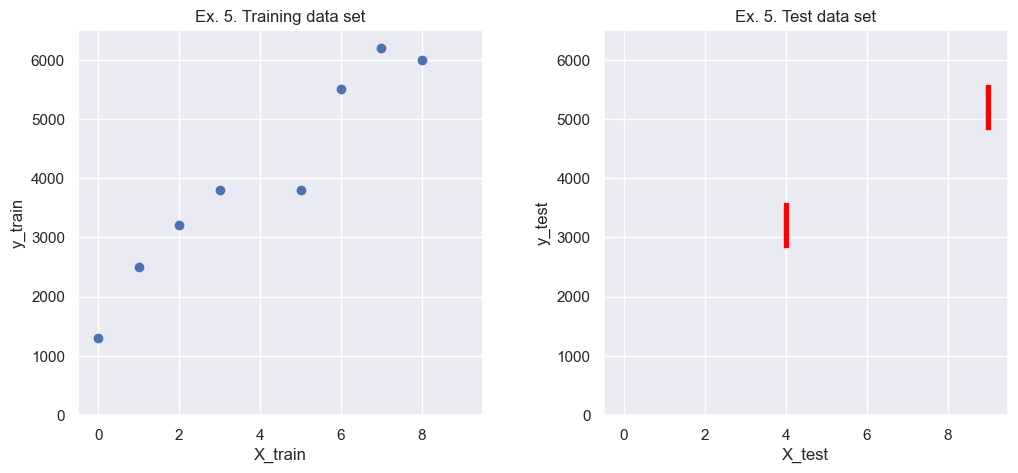

In [27]:
# Data visualization - separation into test and training sets
fig = plt.figure(figsize = (12, 5))

plt.subplot(121)
plt.scatter(X_train, y_train)
plt.title('Ex. 5. Training data set')
plt.xlabel('X_train')
plt.ylabel('y_train')
plt.xlim(-0.5, 9.5)
plt.ylim(0, 6500)

plt.subplot(122)
plt.scatter(X_test, y_test, c = 'red', s = 1000, marker = '$|$')
plt.title('Ex. 5. Test data set')
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.xlim(-0.5, 9.5)
plt.ylim(0, 6500)

plt.subplots_adjust(wspace = 0.3)
plt.show()

In [28]:
# Results and absolute error
pd.DataFrame({'Designation (X_test)': X_test[:, 0], 
              'Actual value (y_test)': y_test, 
              'Value predicted by the model (y_pred)': y_pred, 
              'Difference': abs(y_pred - y_test)})

,Designation (X_test),Actual value (y_test),Value predicted by the model (y_pred),Difference
0,9,5200,4310.888889,889.111111
1,4,3200,3672.000000,472.000000


In [29]:
print(f'The absolute error is {mae:.1f}')

The absolute error is 680.6


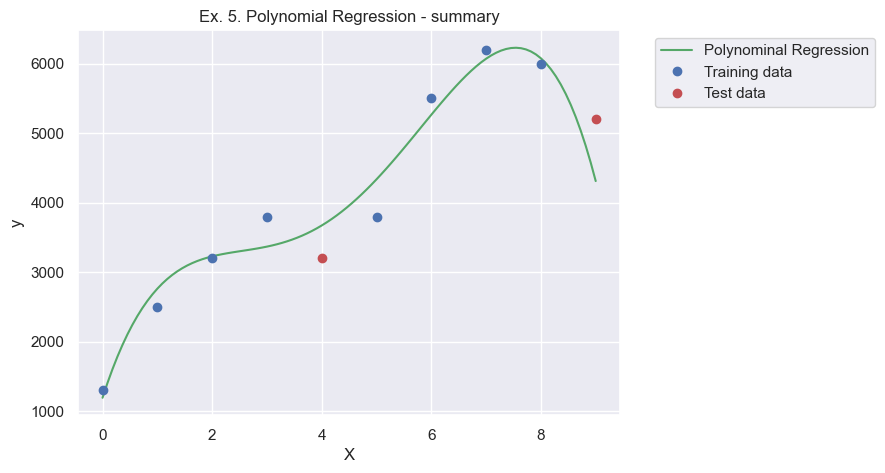

In [30]:
# Data visualization - summary
def y(x):
    return poly.predict(x.reshape(-1, 1))

x = np.linspace(0, 9, 100)

fig = plt.figure(figsize = (7, 5))
plt.plot(x, y(x), 'g-', label = 'Polynominal Regression')
plt.plot(X_train, y_train, 'bo', label = 'Training data')
plt.plot(X_test, y_test, 'ro', label = 'Test data')

plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.title('Ex. 5. Polynomial Regression - summary')
plt.xlabel('X')
plt.ylabel('y')

plt.show()

---
### **Ex. 6. K-Means**
Machine Learning > Unsupervised Learning > Clustering > K-Means

> Take a look: https://scikit-learn.org/stable/modules/clustering.html

In [31]:
# Import required functions
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd

# Input data
X_data = np.array([[12, 5],
                   [15, 4],
                   [12, 3],
                   [0, 0],
                   [1, 1],
                   [0, 1],
                   [-10, -14],
                   [-15, -10],
                   [-14, -12],
                   [-14, -13]])

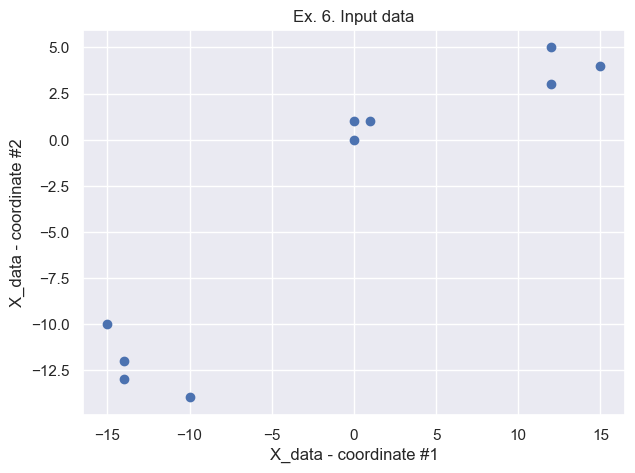

In [32]:
# Data visualization - general
plt.figure(figsize = (7, 5))
plt.scatter(X_data[:, 0], X_data[:, 1])

plt.title('Ex. 6. Input data')
plt.xlabel('X_data - coordinate #1')
plt.ylabel('X_data - coordinate #2')

plt.show()

In [33]:
# Build and set up the model
kmeans = KMeans(n_clusters = 3).fit(X_data)

# Predict based on the model
y_pred = kmeans.predict(X_data)

In [34]:
# Results
pd.DataFrame({'X_data - coordinate #1': X_data[:, 0], 
              'X_data - coordinate #2': X_data[:, 1], 
              'Category determined by the model (y_pred)': y_pred})

,X_data - coordinate #1,X_data - coordinate #2,Category determined by the model (y_pred)
0,12,5,2
1,15,4,2
2,12,3,2
3,0,0,0
4,1,1,0
5,0,1,0
6,-10,-14,1
7,-15,-10,1
8,-14,-12,1
9,-14,-13,1


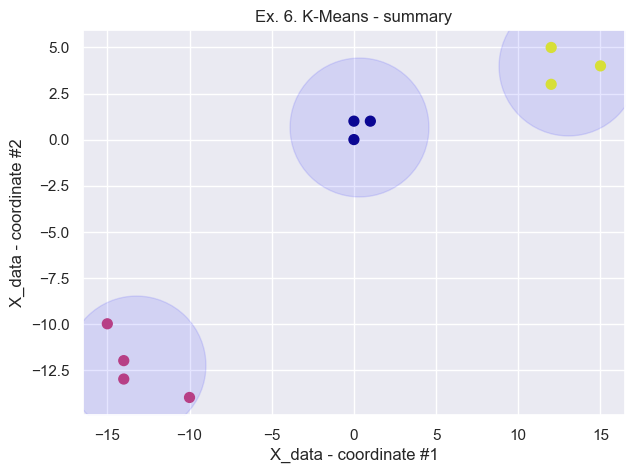

In [35]:
# Data visualization - summary
label = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize = (7, 5))
plt.scatter(X_data[:, 0], X_data[:, 1], c = label, s = 50, cmap = 'plasma')
plt.scatter(centers[:, 0], centers[:, 1], c = 'blue', s = 10000, alpha = 0.1)

plt.title('Ex. 6. K-Means - summary')
plt.xlabel('X_data - coordinate #1')
plt.ylabel('X_data - coordinate #2')

plt.show()

---
### **Ex. 7. OneClassSVM**
Machine Learning > Unsupervised Learning > Anomaly Detection > OneClassSVM

> Take a look: https://scikit-learn.org/stable/modules/outlier_detection.html#outlier-detection

In [36]:
# Import required functions
from sklearn.svm import OneClassSVM

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()


# Input data
X_data_background = np.random.randint(0, 100, size = (20, 2))
X_data_compaction_1 = np.random.randint(60, 70, size = (40, 2))
X_data_compaction_2 = np.random.randint(40, 50, size = (40, 2))
X_data = np.concatenate((X_data_background, X_data_compaction_1, X_data_compaction_2))

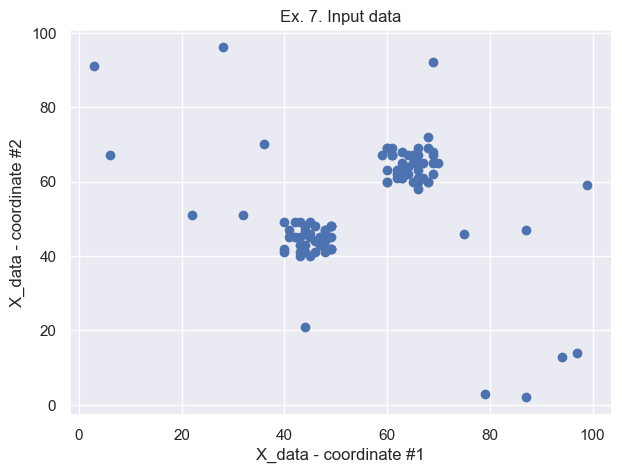

In [37]:
# Data visualization - general
plt.figure(figsize = (7, 5))
plt.scatter(X_data[:, 0], X_data[:, 1])

plt.title('Ex. 7. Input data')
plt.xlabel('X_data - coordinate #1')
plt.ylabel('X_data - coordinate #2')

plt.show()

In [38]:
# Build and set up the model
svm = OneClassSVM().fit(X_data)

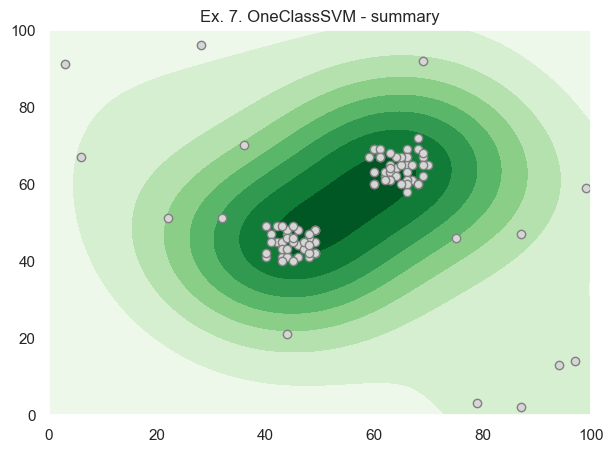

In [39]:
# Data visualization - summary
plt.figure(figsize = (7, 5))
dx_mesh, dy_mesh = np.meshgrid(np.linspace(0, 100, 500), np.linspace(0, 100, 500))
z = svm.decision_function(np.c_[dx_mesh.ravel(), dy_mesh.ravel()])
z = z.reshape(dx_mesh.shape)

plt.title("Ex. 7. OneClassSVM - summary")
plt.contourf(dx_mesh, dy_mesh, z, cmap = 'Greens')
plt.scatter(X_data[:, 0], X_data[:, 1], c = '#d6d6d6', edgecolors = 'gray')
plt.show()